# TCGA–GTEx Tumor–Normal Analysis

**v0.1 educational notebook**

## Goal
Create canonical tumor-versus-normal expression features. The executable v0.1 path uses a small synthetic dataset with ADC-related gene names; the same feature-building function can later be applied to TCGA/GTEx matrices.

**Data mode:** Synthetic executable example + public-data workflow template.

## Canonical guide

### Learning objectives
- Build reusable tumor-versus-normal expression features.
- Separate abundance, selectivity, prevalence, and heterogeneity.
- Prepare a canonical expression table consumed by later notebooks.

### Data mode
Executable core: synthetic TCGA/GTEx-style matrices. Real-data extension: use uniformly processed public expression data after checking sample metadata, gene identifiers, transformation, and access terms.

### Inputs
No external file is required for the executable v0.1 core.

### Canonical outputs
`outputs/tcga_gtex_expression_features.csv`

### Scientific limitation
The synthetic matrix is not TCGA or GTEx data. Cross-cohort tumor/normal comparisons can retain biological and technical confounding even after harmonized processing.

### Next step
Notebook 03 adds normal-tissue protein evidence.


In [1]:
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data'
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print('ROOT:', ROOT.resolve())

ROOT: /mnt/data/audit_adc/adc-scientific-ai


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng=np.random.default_rng(42)
genes=['ERBB2','TACSTD2','NECTIN4','FOLR1','EPCAM']+[f'GENE_{c}' for c in list('ABCDEFGHIJKLMNOPQRS')]
n_tumor,n_normal=80,40
base_t = rng.uniform(2,8,len(genes))
base_n = rng.uniform(0.3,4,len(genes))
# Make educational positives more tumor-enriched
for i in range(4): base_t[i]=rng.uniform(7.5,10); base_n[i]=rng.uniform(0.3,1.5)
tumor = pd.DataFrame({g:np.clip(rng.normal(base_t[i],1.2,n_tumor),0,None) for i,g in enumerate(genes)})
normal = pd.DataFrame({g:np.clip(rng.normal(base_n[i],0.7,n_normal),0,None) for i,g in enumerate(genes)})
# Add heterogeneity to a few genes
for g in ['GENE_B','GENE_H','GENE_N']:
    tumor.loc[:39,g] *= 0.25

In [3]:
def make_expression_features(tumor_expr, normal_expr, prevalence_threshold=4.0):
    out=pd.DataFrame(index=tumor_expr.columns)
    out.index.name='gene_symbol'
    out['tumor_mean']=tumor_expr.mean()
    out['tumor_median']=tumor_expr.median()
    out['tumor_sd']=tumor_expr.std()
    out['tumor_iqr']=tumor_expr.quantile(.75)-tumor_expr.quantile(.25)
    out['normal_mean']=normal_expr.mean()
    out['normal_median']=normal_expr.median()
    out['delta_expression']=out.tumor_median-out.normal_median
    out['tumor_prevalence']=(tumor_expr>=prevalence_threshold).mean()
    out['normal_prevalence']=(normal_expr>=prevalence_threshold).mean()
    return out
expr_features=make_expression_features(tumor,normal)
expr_features.head()

,tumor_mean,tumor_median,tumor_sd,tumor_iqr,normal_mean,normal_median,delta_expression,tumor_prevalence,normal_prevalence
gene_symbol,,,,,,,,,
ERBB2,9.031177,8.929292,0.965318,1.329676,0.567109,0.558175,8.371116,1.0000,0.0
TACSTD2,7.971553,7.896318,1.227710,1.586680,0.496157,0.394122,7.502196,1.0000,0.0
NECTIN4,9.453648,9.346846,1.267520,1.370431,0.997754,1.074437,8.272409,1.0000,0.0
FOLR1,9.435146,9.565760,1.150617,1.648689,1.363935,1.373991,8.191769,1.0000,0.0
EPCAM,2.497228,2.556193,1.238309,1.465133,0.882344,0.732755,1.823439,0.1125,0.0


In [4]:
path=OUTPUTS/'tcga_gtex_expression_features.csv'
expr_features.to_csv(path)
print('saved:', path)

saved: /mnt/data/audit_adc/adc-scientific-ai/outputs/tcga_gtex_expression_features.csv


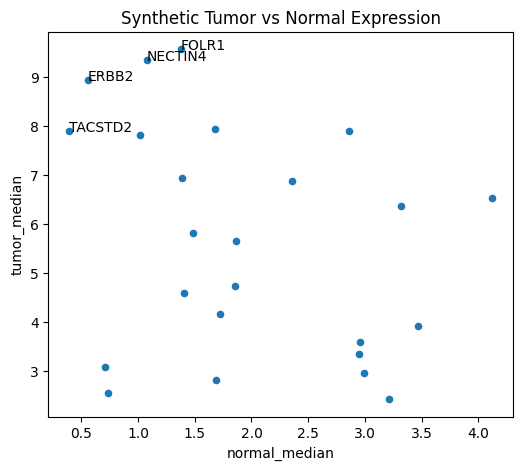

In [5]:
ax=expr_features.plot.scatter(x='normal_median',y='tumor_median',figsize=(6,5),title='Synthetic Tumor vs Normal Expression')
for g in ['ERBB2','TACSTD2','NECTIN4','FOLR1']:
    ax.annotate(g,(expr_features.loc[g,'normal_median'],expr_features.loc[g,'tumor_median']))
plt.show()

## Public-data note
For a real workflow, replace the synthetic matrices with uniformly processed tumor and normal expression matrices, inspect sample metadata and expression scale explicitly, harmonize gene identifiers, and then call the same `make_expression_features` function. Cohort and batch differences must not be ignored.